In [36]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar os dados
wine = load_wine()

In [37]:
# Dataframe para facilitar a visualizacao dos dados
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [38]:
# Task 1: Explorar X e y
print(f"Formato de X (atributos): {wine.data.shape}")
print(f"Formato de y (alvo): {wine.target.shape}")
print(f"Classes do dataset: {wine.target_names}")


Formato de X (atributos): (178, 13)
Formato de y (alvo): (178,)
Classes do dataset: ['class_0' 'class_1' 'class_2']


In [39]:
# Preparando o df
forecasters = wine.data
target = wine.target


In [40]:
# Task 2: train_test_split, treinamento do modelo, previsão e acurácia

# train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(forecasters, target, test_size = 0.3, random_state = 0)

# Carregamento e treinamento do modelo
naive_bayes = GaussianNB()
naive_bayes.fit(X_train, Y_train)
forecasts = naive_bayes.predict(X_test)

# Checagem da previsão
accuracy = accuracy_score(Y_test, forecasts)


print(f"Acurácia do modelo original (13 atributos): {accuracy * 100:.2f}%")


Acurácia do modelo original (13 atributos): 94.44%


In [41]:
# Task 3: Seleção de atributos

selection = SelectKBest(chi2, k = 7)
new_X = selection.fit_transform(forecasters, target)


In [42]:
# Task 4: Treinamento do modelo com os atributos selecionados

# train_test_split
X_train_new, X_test_new, Y_train_new, Y_test_new = train_test_split(new_X, target, test_size = 0.3, random_state = 0)

# Carregamento e treinamento do novo modelo
naive_bayes_selected = GaussianNB()
naive_bayes_selected.fit(X_train_new, Y_train_new)
new_forecasts = naive_bayes_selected.predict(X_test_new)

# Checagem da previsão

new_accuracy = accuracy_score(Y_test_new, new_forecasts)


print(f"Acurácia do modelo com seleção (7 atributos): {new_accuracy * 100:.2f}%")


Acurácia do modelo com seleção (7 atributos): 92.59%


## Task 5: Conclusão

Neste projeto, realizei uma comparação entre um modelo de classificação Naive Bayes (GaussianNB) utilizando o conjunto total de atributos e uma versão otimizada via Feature Selection.

#### Comparativo de Performance:

| Cenário | Atributos | Acurácia Obtida |
| :--- | :---: | :---: |
| **Modelo Original** | 13 | **94.44%** |
| **Modelo com Seleção (SelectKBest)** | 7 | **92.59%** |

#### Principais Insights: 
Eficiência vs Complexidade: Ao reduzir o número de atributos em aproximadamente 46% (de 13 para 7), podemos observar uma queda de apenas 1.85% na acurácia. 
Viabilidade Técnica: A utilização do teste estatístico Chi-Squared ($\chi^2$) no SelectKBest mostrou-se eficaz para identificar as variáveis com maior dependência em relação às classes de vinho, permitindo a criação de um modelo mais leve e rápido.
Conclusão Final: O modelo simplificado é preferível para ambientes de produção que exijam menor custo computacional, visto que a pequena perda de acurácia é compensada pela redução significativa na dimensionalidade dos dados.

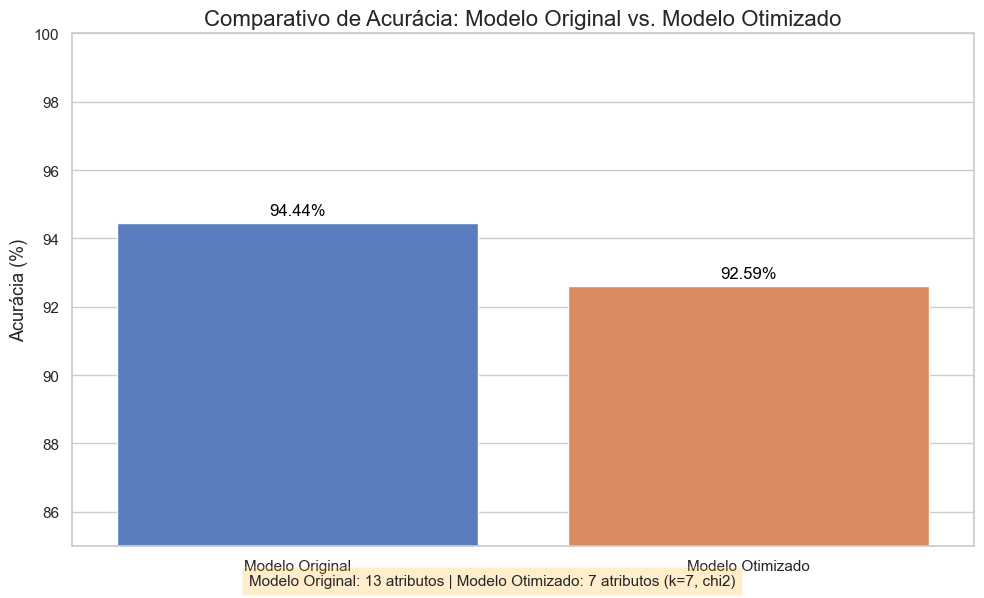

In [43]:
# Task 6 (Bônus): Visualização de Resultados

# Preparando os dados para o gráfico
dados_grafico = {
    'Cenário': ['Modelo Original', 'Modelo Otimizado'],
    'Acurácia': [accuracy * 100, new_accuracy * 100], 
    'Atributos': [13, 7]
}
df_resultados = pd.DataFrame(dados_grafico)

# Configurando o estilo e criar o gráfico de barras
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Criando o gráfico de barras para Acurácia
ax = sns.barplot(x='Cenário', y='Acurácia', data=df_resultados, hue='Cenário', palette='muted', legend=False)

# Adicionando os rótulos de dados 
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=12, color='black', xytext=(0, 9), 
                textcoords='offset points')

# Customizando títulos e eixos
plt.title('Comparativo de Acurácia: Modelo Original vs. Modelo Otimizado', fontsize=16)
plt.ylabel('Acurácia (%)', fontsize=13)
plt.xlabel('') 
plt.ylim(85, 100) 

# Adicionando a informação dos atributos como texto secundário
plt.figtext(0.5, 0.01, 'Modelo Original: 13 atributos | Modelo Otimizado: 7 atributos (k=7, chi2)', 
            ha="center", fontsize=11, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

# Gráfico
plt.tight_layout()
plt.show()